In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
y0= 3.40 #Å
E0 = 0.0104 #ev
x0 = 3.808#Å #Point of minima of the PE. Obtained from the material shared
dt = 0.001 #ps
n = 10000
m0 =39.948*1.66053906660e-27  #Kg
v0=2

For the particle to oscillate, Total Energy must be negative

E = KE + PE < 0 => KE < -PE

KE = (m*v**2)/2 = epsilon

v < sqrt(epsilon*2/m)

v < 224m/s

as x and dt are in Angstrom and picoseconds v< 2.2 Å /ps

assuming v0 = 2 Å /ps

In [ ]:
def potential(x,y=y0,E=E0):
    return 4*E*( ((y/x)**12) - ((y/x)**6))
#eV

In [ ]:
def force(x,y=y0 ,E=E0):
    return 4*E*((((12*y**12)/(x**13)))-(((6*y**6)/(x**7))))
#ev/Å


In [ ]:
def acceleration(x, m = m0):
    return (force(x)*1.602*10**(-23))/m

In [ ]:
def Kinetic_Energy(v, m=m0):
    return ((m*v**2)*10**23)/(2*1.602)

Verlet Algorithm

In [ ]:
x_ver = np.zeros(n+1 ,dtype=float)
a = np.zeros(n+1,dtype=float)
v_ver=np.zeros(n,dtype=float)

x_ver[0] = x0
x_ver[1] = x0 + v0*dt
v_ver[0] = v0
a[0] = acceleration(x_ver[0])
a[1] = acceleration(x_ver[1])

In [ ]:
for i in range(2,n+1):
    x_ver[i] = 2*(x_ver[i-1]) + a[i-1]*dt*dt - x_ver[i-2]
    v_ver[i-1] = (x_ver[i] - x_ver[i-2])/(2*dt)
    a[i] = acceleration(x_ver[i])

In [ ]:
x_ver

array([3.808     , 3.81      , 3.81200008, ..., 5.25838459, 5.25896598,
       5.25954666], shape=(100001,))

In [ ]:
x_ver = x_ver[:-1]#to reduce the size of x from 10001 to 10000
x_ver


array([3.808     , 3.81      , 3.81200008, ..., 5.25780249, 5.25838459,
       5.25896598], shape=(100000,))

In [ ]:
F = force(x_ver)
U = potential(x_ver)

U.size

100000

Text(0.5, 1.0, 'F Vs Position')

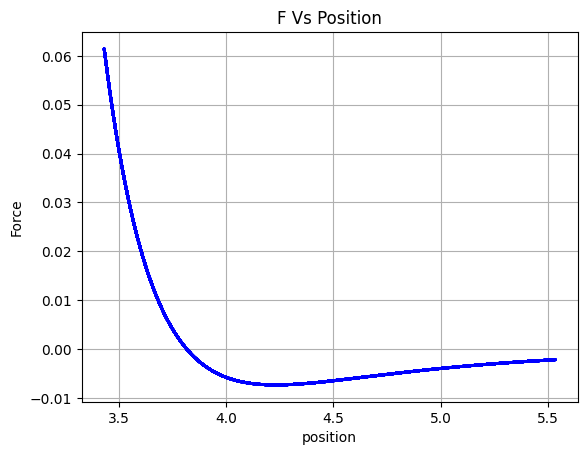

In [ ]:


plt.plot(x_ver,F,lw=2,color='b')
plt.grid()
plt.xlabel('position')
plt.ylabel('Force')
plt.title("F Vs Position")

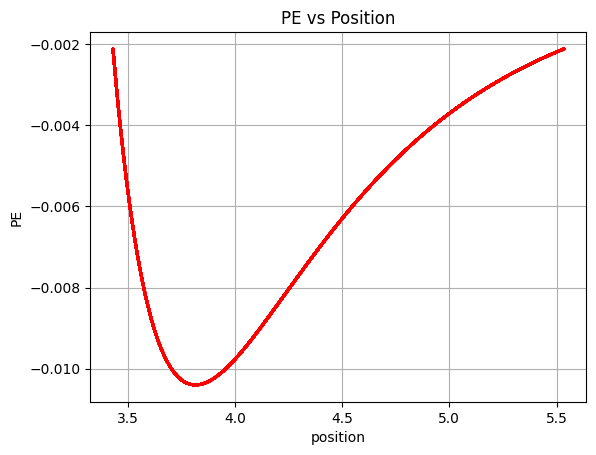

In [ ]:
plt.plot(x_ver,U,lw=2,color='r')
plt.grid()
plt.title("PE vs Position")
plt.xlabel('position')
plt.ylabel('PE')
plt.show()

In [ ]:
minimum_index = np.argmin(U)
minimum_index = x_ver[minimum_index]

print("The minimum potential energy is at x = ",minimum_index, "Å")
print("The force at the minima of potential Energy is F =", force(minimum_index ),"eV/Å")

The minimum potential energy is at x =  3.8163520067677252 Å
The force at the minima of potential Energy is F = 9.746933949781322e-07 eV/Å


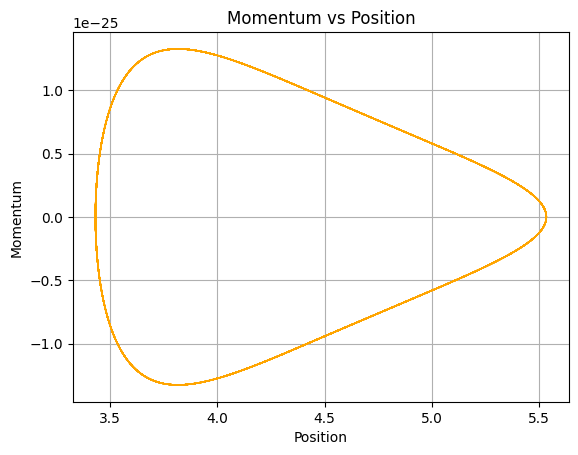

In [ ]:
plt.Figure(figsize=(10,7))
plt.plot(x_ver,m0*v_ver,color='orange',lw=1,ls='--')
plt.grid()
plt.title('Momentum vs Position')
plt.xlabel('Position')
plt.ylabel('Momentum')
plt.show()

Time Sensitivity

Although a larger time step would speed up computation, it could also result in numerical errors, energy drift, and instability. On the other hand, longer simulation times result from a smaller time step, which also improves accuracy. The system's overall energy is well-conserved, according to the "Energy vs. Time" plot, suggesting that the dt of 0.001 ps selected is suitable and offers adequate accuracy for this simulation

The oscillations become unstable when the total Energy of the system E > 0.

For a given velocity v0, we can mathematically find the minimum initial position x0 required for stable oscillations by ensuring the total energy E < 0.

The total energy is given by:[ E = KE + PE = (m v0^2)/2 + U(x0) ] where U(x0) is the Lennard-Jones potential at x0.

Setting E = 0 gives the threshold for instability:[(m v0^2)/2 + U(x0) = 0][U(x_0) = - (m v_0^2)/2]

To find the minimum x0 for a given v0, we solve for x0 such that the potential energy at x0 equals - (m v0^2)/2 .

For v0 = 2 Å/ps and m = 6.63*10^{-26} kg , and converting the kinetic energy to eV we get: [ KE = 0.008280368450278923 eV ]

Calculate U(x0) using the Lennard-Jones potential and solve for x0 numerically to find the minimum position for stability.

In [ ]:
Kinetic_Energy(v0)

0.00828154989170247

In [ ]:
t = np.zeros(n, dtype=float)
for i in range(n):
    t[i] = i*dt

In [ ]:
t

array([0.0000e+00, 1.0000e-03, 2.0000e-03, ..., 9.9997e+01, 9.9998e+01,
       9.9999e+01], shape=(100000,))

In [ ]:
K = Kinetic_Energy(v_ver)
TE= K + U

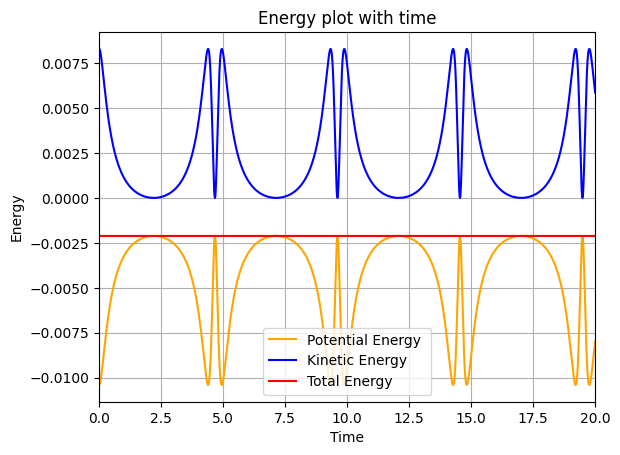

In [ ]:
plt.Figure(figsize=(17,11))
plt.xlim([0.0,10.0])
plt.plot(t,U, color = 'orange')
plt.plot(t,K, color = 'b' )
plt.plot(t,TE, color = 'red')
plt.grid()
plt.legend(['Potential Energy ', 'Kinetic Energy ','Total Energy '])
plt.xlim(0,20)
plt.title("Energy plot with time")
plt.xlabel('Time')
plt.ylabel('Energy')
plt.show()

Energy Conservation:

1.The total energy(black)should remain nearly constant that confirms the verlet algorithm conserves energy well for small dt

. Minor fluctuations are expected due to numerical rounding but should not drift significantly.

2. Energy Exchange

. As the oscillator moves, kinetic energy (blue) and potential energy (red) oscillate out of phase:

. When x is near equilibrium - KE is maximum, PE is minimum.

. At turning points - KE is minimum, PE is maximum.